# Math2LaTeX & Word Export Pipeline
This notebook tests the `pix2tex` model. It will visually render the math for you to read, and compile everything into a `.docx` file containing the original image, the rendered equation, and the raw LaTeX.

In [7]:
%pip install pix2tex Pillow numpy python-docx requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 24.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [python-docx]
Note: you may need to restart the kernel to use updated packages.


In [8]:
import os
import urllib.parse
import requests
from io import BytesIO
import numpy as np
from PIL import Image
from pix2tex.cli import LatexOCR
from docx import Document
from docx.shared import Inches
from IPython.display import display, Math, Markdown

class Math2LaTeXPipeline:
    def __init__(self):
        print("Loading Math2LaTeX model into memory...")
        self.model = LatexOCR()
        print("Model loaded successfully!")

    def extract_latex(self, image_input):
        if isinstance(image_input, Image.Image):
            img = image_input
        elif isinstance(image_input, str):
            img = Image.open(image_input)
        else:
            raise ValueError("Must be PIL Image or file path.")

        if img.mode != 'RGB':
            img = img.convert('RGB')

        try:
            return self.model(img)
        except Exception as e:
            return f"Error processing image: {str(e)}"

def render_latex_to_png(latex_str):
    """ Uses a free API to convert LaTeX into an image for the Word Doc """
    encoded = urllib.parse.quote(latex_str)
    url = f"https://latex.codecogs.com/png.image?\dpi{{300}}\bg_white\space {encoded}"
    response = requests.get(url)
    if response.status_code == 200:
        return BytesIO(response.content)
    return None

In [9]:
# Initialize the AI Pipeline (downloads model if first time)
pipeline = Math2LaTeXPipeline()

Loading Math2LaTeX model into memory...
Model loaded successfully!


In [10]:
# Create testing directory
test_dir = 'test_math_images'
os.makedirs(test_dir, exist_ok=True)
print(f"Directory created: '{test_dir}/'")
print("\n-> ACTION REQUIRED: Put some math images (.png or .jpg) into the 'test_math_images' folder before running the next cell.")

Directory created: 'test_math_images/'

-> ACTION REQUIRED: Put some math images (.png or .jpg) into the 'test_math_images' folder before running the next cell.


---
### Processing: `test2.png`

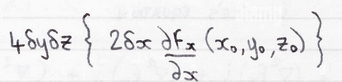

**Rendered Result:**

<IPython.core.display.Math object>

**Raw Code:** `{\downarrow\leq\uparrow\uparrow\uparrow}\\ {\downarrow\uparrow\uparrow}\end{array}\bigg\langle\mathrm{~\uparrow~}\Sigma\S_{\infty}\ <{\vartheta\uparrow\downarrow\downarrow\atop\downarrow\downarrow\downarrow\uparrow\leq\rangle}\bigg\rangle\bigg\rangle`

---
### Processing: `test1.png`

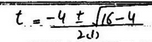

**Rendered Result:**

<IPython.core.display.Math object>

**Raw Code:** `\scriptstyle{\frac{\theta=a{\sqrt{b(a)}}}{2\sin\theta}}\,`

---
### Processing: `test3.png`

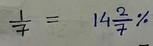

**Rendered Result:**

<IPython.core.display.Math object>

**Raw Code:** `\begin{array}{r l}{{\frac{1}{\pi}}}&{{}=_{\circ}}&{{}|2|{\frac{x_{\circ}}{T}}\chi}\\ {\equiv}&{{}=\sin\theta\sin\theta}\end{array}`

---
# ✅ Done! Check your folder for `Exported_Math_Results.docx`

In [11]:
# Process images and create Word Document
valid_extensions = ('.png', '.jpg', '.jpeg')
images = [f for f in os.listdir(test_dir) if f.lower().endswith(valid_extensions)]

if not images:
    print(f"No images found in '{test_dir}/'. Please add some.")
else:
    # Initialize Word Document
    doc = Document()
    doc.add_heading('Math Image to LaTeX Extraction Results', 0)
    
    for img_name in images:
        img_path = os.path.join(test_dir, img_name)
        
        # 1. Display Image in Jupyter
        display(Markdown(f"---\n### Processing: `{img_name}`"))
        img = Image.open(img_path)
        # Scale down for Jupyter display if too large
        img.thumbnail((400, 400))
        display(img)
        
        # 2. Extract LaTeX
        latex_code = pipeline.extract_latex(img_path)
        
        # 3. Display Visually Rendered Math in Jupyter
        display(Markdown("**Rendered Result:**"))
        display(Math(latex_code))
        display(Markdown(f"**Raw Code:** `{latex_code}`"))
        
        # 4. Add to Word Document
        doc.add_heading(f'Result for: {img_name}', level=1)
        doc.add_paragraph("Original Upload:")
        doc.add_picture(img_path, width=Inches(3.0)) # Add original image
        
        doc.add_paragraph("Rendered Math Equation:")
        rendered_png_stream = render_latex_to_png(latex_code)
        if rendered_png_stream:
            doc.add_picture(rendered_png_stream, width=Inches(3.5)) # Add generated math image
        else:
            doc.add_paragraph("(Could not fetch rendered image from API)")
            
        doc.add_paragraph("Raw LaTeX Code:")
        code_paragraph = doc.add_paragraph(latex_code)
        code_paragraph.style = 'Intense Quote'
        
    # Save the document!
    word_file_name = 'Exported_Math_Results.docx'
    doc.save(word_file_name)
    display(Markdown(f"---\n# ✅ Done! Check your folder for `{word_file_name}`"))